In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
df = pd.read_csv('../data/housing_clean.csv')
df.head(10)


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2
5,7237550310,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930,2014,5
6,1321400060,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819,2014,6
7,2008000270,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711,2015,1
8,2414600126,229500.0,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113,2015,4
9,3793500160,323000.0,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570,2015,3


In [24]:
model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=3)

In [25]:
X = df.drop('price', axis =1)
y = df['price']

In [26]:
X.head(10)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,7129300520,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,6414100192,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,5631500400,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,2487200875,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,1954400510,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2
5,7237550310,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930,2014,5
6,1321400060,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819,2014,6
7,2008000270,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711,2015,1
8,2414600126,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113,2015,4
9,3793500160,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570,2015,3


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17289, 21)
X_test shape: (4323, 21)


(test) Root Mean Squared Error: 138137.45
(test) Mean Squared Error: 19081953785.58
(test) Absolute Squared Error: 68372.68
(test) R-squared: 0.87
(train) Root Mean Squared Error: 53442.07
(train) Mean Squared Error: 2856055009.04
(train) Absolute Squared Error: 38170.54
(train) R-squared: 0.98


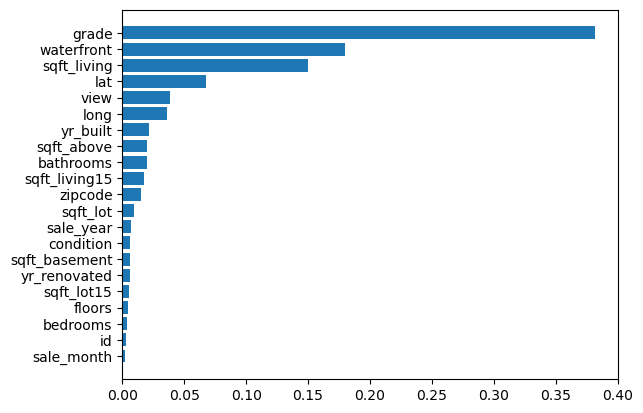

In [37]:
model1 = XGBRegressor()
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)
y_pred_train = model1.predict(X_train)

test_rmse = np.sqrt(mean_squared_error(y_test,y_pred))
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

train_rmse = np.sqrt(mean_squared_error(y_train,y_pred_train))
train_mse = mean_squared_error(y_train, y_pred_train)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"(test) Root Mean Squared Error: {test_rmse:.2f}")
print(f"(test) Mean Squared Error: {test_mse:.2f}")
print(f"(test) Absolute Squared Error: {test_mae:.2f}")
print(f"(test) R-squared: {test_r2:.2f}")

print(f"(train) Root Mean Squared Error: {train_rmse:.2f}")
print(f"(train) Mean Squared Error: {train_mse:.2f}")
print(f"(train) Absolute Squared Error: {train_mae:.2f}")
print(f"(train) R-squared: {train_r2:.2f}")

model1.feature_importances_
sort_idx = model1.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],model1.feature_importances_[sort_idx])
plt.show()

In [40]:
model1.get_params(deep=True)

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

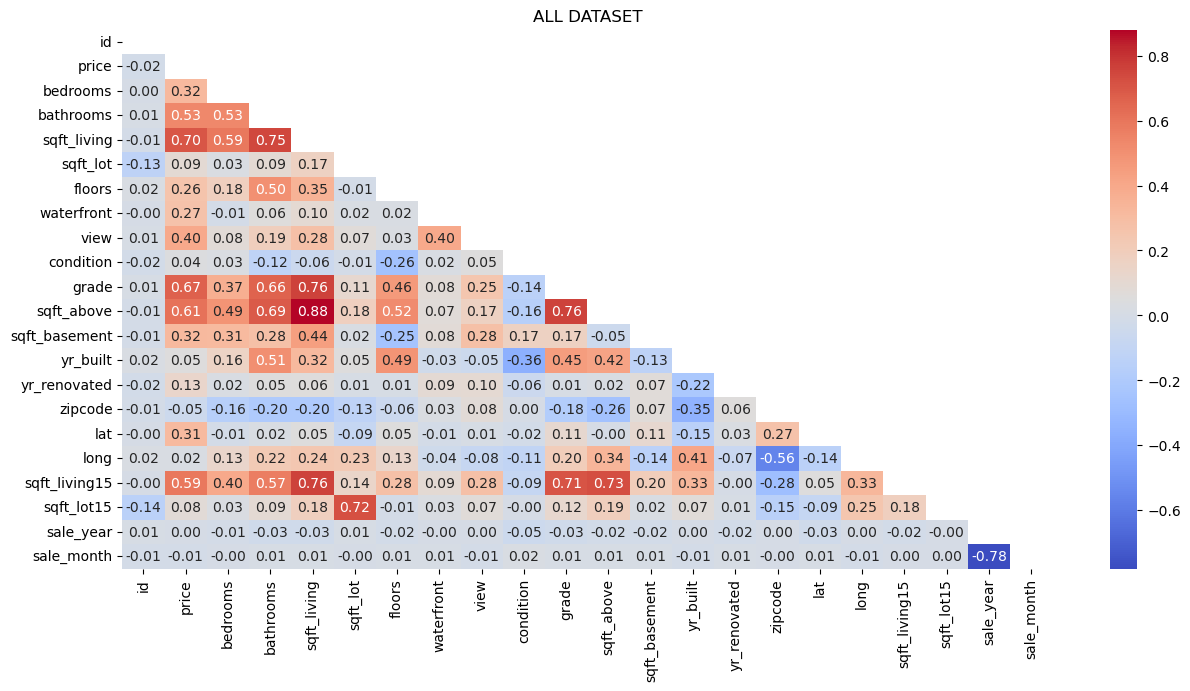

In [42]:
correlation_matrix = round(df[df.columns].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("ALL DATASET")
plt.show()

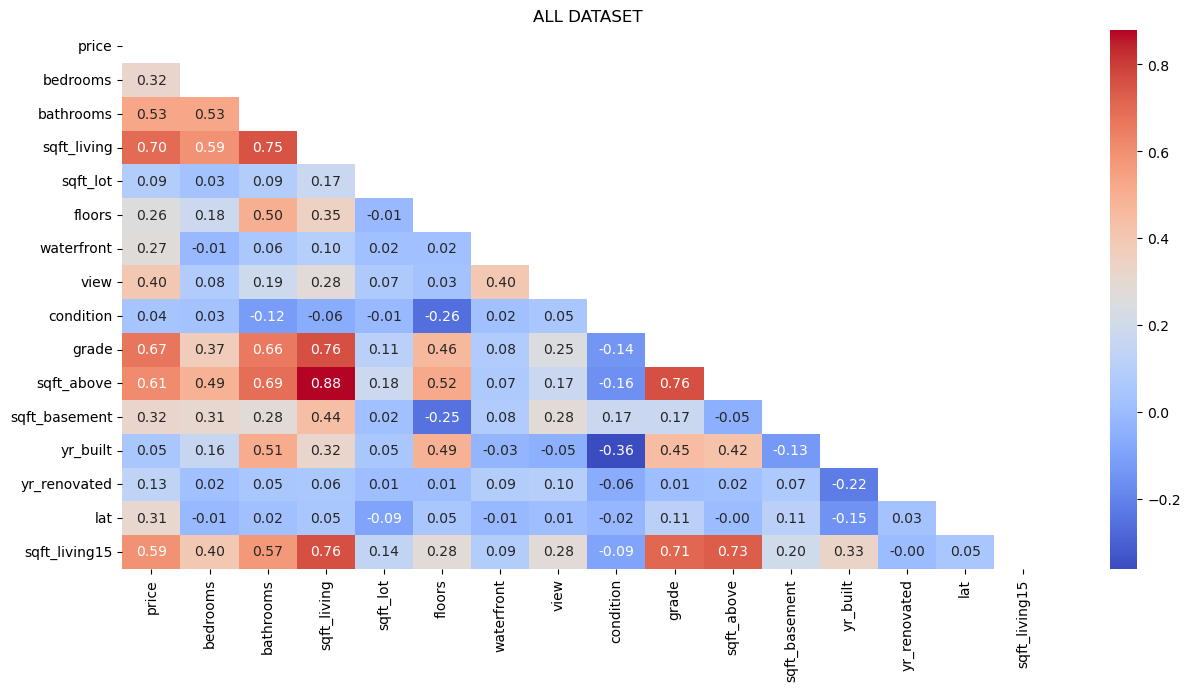

In [45]:
df2 = df.drop(['id', 'sale_month','sale_year','sqft_lot15','long','zipcode'], axis = 1)
correlation_matrix = round(df2[df2.columns].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("ALL DATASET")
plt.show()

X_train shape: (17289, 15)
X_test shape: (4323, 15)
(test) Root Mean Squared Error: 170449.96
(test) Mean Squared Error: 29053187210.47
(test) Absolute Squared Error: 83006.90
(test) R-squared: 0.81
(train) Root Mean Squared Error: 69917.72
(train) Mean Squared Error: 4888487017.01
(train) Absolute Squared Error: 48882.00
(train) R-squared: 0.96


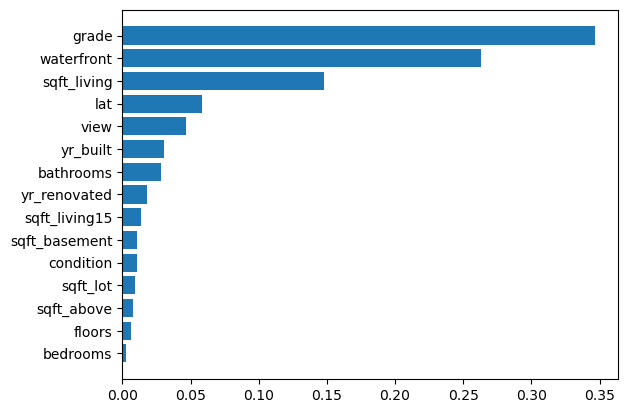

In [ ]:
X2 = df2.drop('price', axis =1)
y2 = df2['price']
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

model1 = XGBRegressor()
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)
y_pred_train = model1.predict(X_train)

test_rmse = np.sqrt(mean_squared_error(y_test,y_pred))
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

train_rmse = np.sqrt(mean_squared_error(y_train,y_pred_train))
train_mse = mean_squared_error(y_train, y_pred_train)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"(test) Root Mean Squared Error: {test_rmse:.2f}")
print(f"(test) Mean Squared Error: {test_mse:.2f}")
print(f"(test) Absolute Squared Error: {test_mae:.2f}")
print(f"(test) R-squared: {test_r2:.2f}")

print(f"(train) Root Mean Squared Error: {train_rmse:.2f}")
print(f"(train) Mean Squared Error: {train_mse:.2f}")
print(f"(train) Absolute Squared Error: {train_mae:.2f}")
print(f"(train) R-squared: {train_r2:.2f}")

model1.feature_importances_
sort_idx = model1.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],model1.feature_importances_[sort_idx])
plt.show()



# TRY REMOVE OUTLIERS

In [61]:
def identify_outliers_iqr(df, column, threshold=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for column in df2.columns:
    column_out, column_lower, column_upper = identify_outliers_iqr(df2, column)
    print(f'{column}: {len(column_out)}\nbounds: {column_lower:.2f} to {column_upper:.2f}\nminmax: {df2[column].min()} to {df2[column].max()}\n')

price: 1146
bounds: -162906.25 to 1129743.75
minmax: 75000.0 to 7700000.0

bedrooms: 545
bounds: 1.50 to 5.50
minmax: 0 to 11

bathrooms: 571
bounds: 0.62 to 3.62
minmax: 0.0 to 8.0

sqft_living: 572
bounds: -258.75 to 4235.25
minmax: 290 to 13540

sqft_lot: 2425
bounds: -3432.38 to 19160.62
minmax: 520 to 1651359

floors: 0
bounds: -0.50 to 3.50
minmax: 1.0 to 3.5

waterfront: 163
bounds: 0.00 to 0.00
minmax: 0 to 1

view: 2124
bounds: 0.00 to 0.00
minmax: 0 to 4

condition: 30
bounds: 1.50 to 5.50
minmax: 1 to 5

grade: 1911
bounds: 5.50 to 9.50
minmax: 1 to 13

sqft_above: 611
bounds: -340.00 to 3740.00
minmax: 290 to 9410

sqft_basement: 496
bounds: -840.00 to 1400.00
minmax: 0 to 4820

yr_built: 0
bounds: 1882.00 to 2066.00
minmax: 1900 to 2015

yr_renovated: 914
bounds: 0.00 to 0.00
minmax: 0 to 2015

lat: 2
bounds: 47.16 to 47.99
minmax: 47.1559 to 47.7776

sqft_living15: 544
bounds: 185.00 to 3665.00
minmax: 399 to 6210



In [29]:
# Define XGBRegressor model parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.1,
    'n_estimators': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE
}

# Instantiate XGBRegressor with the parameters
model = XGBRegressor(**params)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 132868058339.56
R-squared: 0.11
